# Analisis Perilaku Pendengar dan Prediksi Churn Spotify 2025

---

**NIM / Nama** : 247411027 — Anwar Rohmadi  
**Dataset** : Spotify Churn Dataset 2025 — 8.000 observasi, 12 variabel  
**Metode Korelasi** : Spearman Rank Correlation *(dipilih berdasarkan uji komparatif terhadap Pearson dan Kendall)*

---

## Latar Belakang

Platform streaming musik seperti Spotify menghadapi tantangan utama berupa *customer churn* — kondisi di mana pengguna aktif berhenti menggunakan layanan. Memahami pola perilaku pendengar secara kuantitatif menjadi prasyarat dalam merancang strategi retensi yang efektif.

Analisis ini bertujuan untuk:

1. Mengidentifikasi pola aktivitas mendengarkan berdasarkan dimensi demografi (gender dan negara).
2. Mengukur kekuatan dan arah hubungan antarvariabel kunci menggunakan metode korelasi yang paling sesuai secara statistik.
3. Mengungkap faktor-faktor perilaku yang paling berkontribusi terhadap risiko churn melalui pemodelan prediktif.
4. Merumuskan rekomendasi strategis berbasis data untuk meningkatkan retensi dan akuisisi pengguna.


## 0. Persiapan Lingkungan Analisis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from scipy.stats import pearsonr, spearmanr, kendalltau, kruskal, chi2_contingency, pointbiserialr
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

# Palet warna profesional — monokromatik dengan aksen minimal
COLORS = {
    'primary'   : '#2C6E8A',   # biru teal gelap
    'secondary' : '#5B8E7D',   # hijau sage
    'accent'    : '#C07D59',   # terra cotta
    'neutral'   : '#8C8C8C',   # abu-abu medium
    'light'     : '#D9D9D9',   # abu-abu muda
    'danger'    : '#A63D2F',   # merah gelap
    'warning'   : '#C9A84C',   # kuning mustard
}

PALETTE_SEQ   = ['#2C6E8A', '#3D8FA8', '#5B8E7D', '#7DAA9B', '#C07D59', '#D9A57E']
PALETTE_DIV   = 'RdBu_r'
PALETTE_SEQ2  = 'Blues'

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F8F9FA',
    'axes.edgecolor'   : '#CCCCCC',
    'axes.labelcolor'  : '#333333',
    'axes.titlecolor'  : '#1A1A1A',
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
    'xtick.color'      : '#555555',
    'ytick.color'      : '#555555',
    'text.color'       : '#333333',
    'grid.color'       : '#E0E0E0',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'figure.dpi'       : 110,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print("Lingkungan analisis berhasil dikonfigurasi.")


Lingkungan analisis berhasil dikonfigurasi.


## 1. Pemuatan dan Pemahaman Dataset

In [2]:
df = pd.read_csv('spotify_churn_dataset.csv')

print(f"Dimensi dataset  : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Data duplikat    : {df.duplicated().sum()}")
print(f"Nilai hilang     : {df.isnull().sum().sum()}")
print()
display(df.head(5))


Dimensi dataset  : 8,000 baris x 12 kolom
Data duplikat    : 0
Nilai hilang     : 0



,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [3]:
print("Statistik Deskriptif — Variabel Numerik")
display(df.describe().T.round(3))


Statistik Deskriptif — Variabel Numerik


,count,mean,std,min,25%,50%,75%,max
user_id,8000.0,4000.500,2309.545,1.0,2000.75,4000.5,6000.25,8000.0
age,8000.0,37.662,12.740,16.0,26.00,38.0,49.00,59.0
listening_time,8000.0,154.068,84.016,10.0,81.00,154.0,227.00,299.0
songs_played_per_day,8000.0,50.127,28.450,1.0,25.00,50.0,75.00,99.0
skip_rate,8000.0,0.300,0.174,0.0,0.15,0.3,0.45,0.6
ads_listened_per_week,8000.0,6.944,13.618,0.0,0.00,0.0,5.00,49.0
offline_listening,8000.0,0.748,0.434,0.0,0.00,1.0,1.00,1.0
is_churned,8000.0,0.259,0.438,0.0,0.00,0.0,1.00,1.0


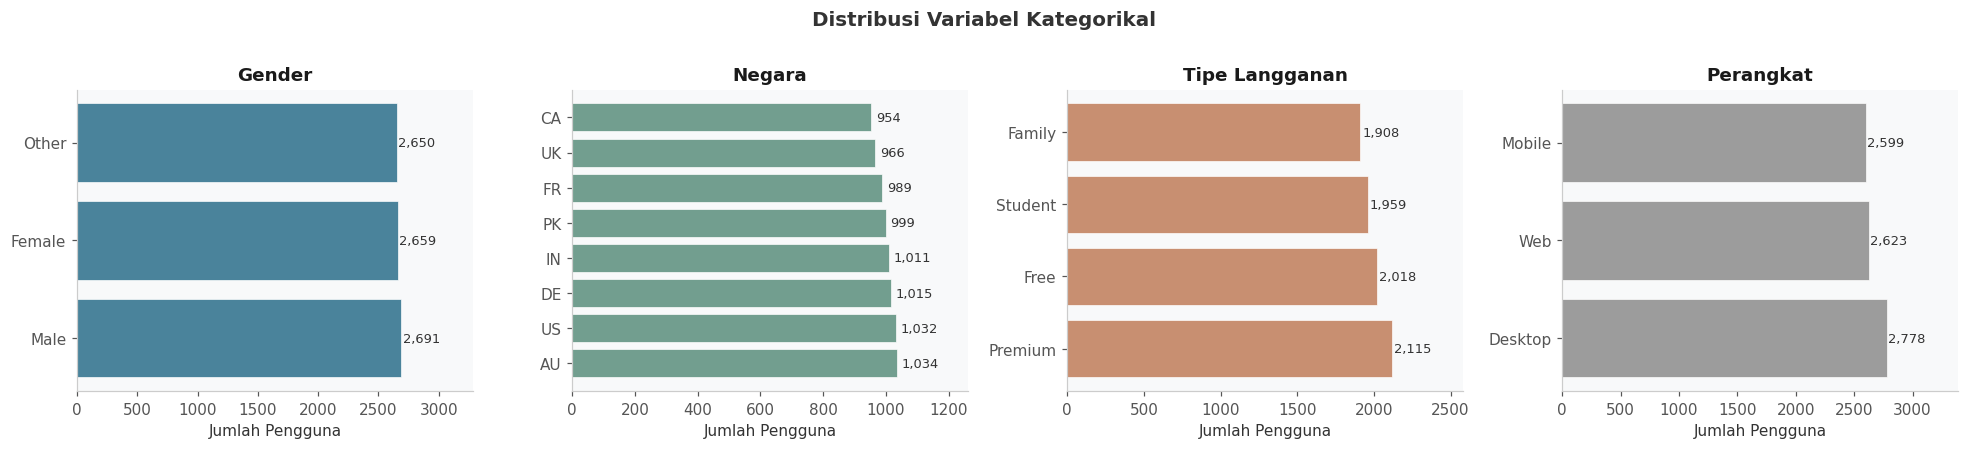

Tingkat churn keseluruhan: 25.89% dari 8,000 pengguna


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Distribusi Variabel Kategorikal', fontsize=13, fontweight='semibold', y=1.01)

cat_info = [
    ('gender', 'Gender', COLORS['primary']),
    ('country', 'Negara', COLORS['secondary']),
    ('subscription_type', 'Tipe Langganan', COLORS['accent']),
    ('device_type', 'Perangkat', COLORS['neutral']),
]

for ax, (col, title, color) in zip(axes, cat_info):
    counts = df[col].value_counts()
    bars = ax.barh(counts.index, counts.values, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontweight='semibold')
    ax.set_xlabel('Jumlah Pengguna')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=8.5)
    ax.set_xlim(0, counts.max() * 1.22)

plt.tight_layout()
plt.savefig('fig_kategorikal.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"Tingkat churn keseluruhan: {df['is_churned'].mean()*100:.2f}% dari {len(df):,} pengguna")


---
## 2. Pola Aktivitas Mendengarkan Berdasarkan Demografi

### 2.1 Rata-rata Lagu Per Hari Menurut Gender


In [5]:
avg_gender = (
    df.groupby('gender')
      .agg(
          rata_rata_lagu     = ('songs_played_per_day', 'mean'),
          median_lagu        = ('songs_played_per_day', 'median'),
          listening_time_avg = ('listening_time', 'mean'),
          jumlah_pengguna    = ('user_id', 'count'),
      )
      .round(2)
      .sort_values('rata_rata_lagu', ascending=False)
      .reset_index()
)
avg_gender.columns = ['Gender', 'Rata-rata Lagu/Hari', 'Median Lagu/Hari',
                       'Avg Listening Time (mnt)', 'Jumlah Pengguna']
display(avg_gender)


,Gender,Rata-rata Lagu/Hari,Median Lagu/Hari,Avg Listening Time (mnt),Jumlah Pengguna
0,Other,50.57,51.0,154.73,2650
1,Male,50.13,50.0,153.62,2691
2,Female,49.68,50.0,153.86,2659


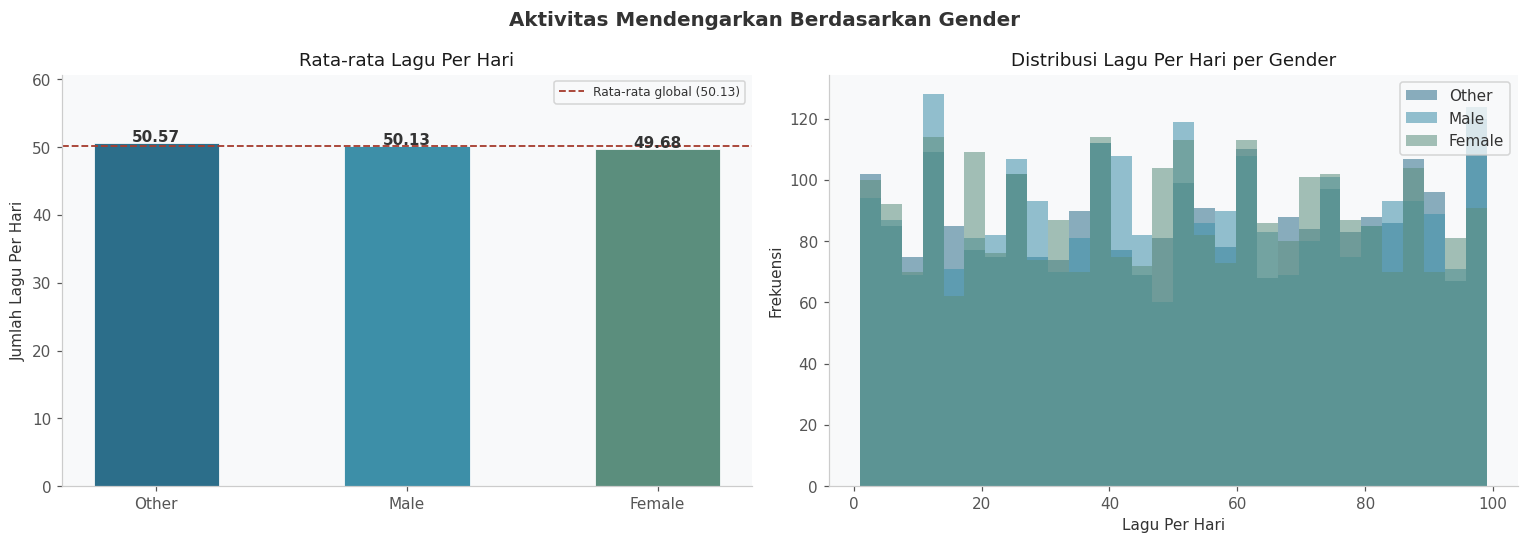

Catatan: Selisih rata-rata antar gender kurang dari 1 lagu per hari.
Hasil ini mengindikasikan bahwa gender bukan faktor pembeda perilaku mendengarkan yang bermakna.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Aktivitas Mendengarkan Berdasarkan Gender', fontsize=13, fontweight='semibold')

genders  = avg_gender['Gender'].tolist()
songs    = avg_gender['Rata-rata Lagu/Hari'].tolist()
lt_vals  = avg_gender['Avg Listening Time (mnt)'].tolist()
global_mean = df['songs_played_per_day'].mean()

bars0 = axes[0].bar(genders, songs, color=PALETTE_SEQ[:3], edgecolor='white', linewidth=0.5, width=0.5)
axes[0].axhline(global_mean, color=COLORS['danger'], linestyle='--', linewidth=1.2,
                label=f'Rata-rata global ({global_mean:.2f})')
axes[0].set_ylabel('Jumlah Lagu Per Hari')
axes[0].set_title('Rata-rata Lagu Per Hari')
axes[0].set_ylim(0, max(songs) * 1.2)
for bar, val in zip(bars0, songs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='semibold')
axes[0].legend(fontsize=8)

for g, color in zip(genders, PALETTE_SEQ[:3]):
    data = df[df['gender'] == g]['songs_played_per_day']
    axes[1].hist(data, bins=30, alpha=0.55, label=g, color=color, edgecolor='none')
axes[1].set_xlabel('Lagu Per Hari')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Lagu Per Hari per Gender')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_gender_lagu.png', bbox_inches='tight', dpi=120)
plt.show()

print("Catatan: Selisih rata-rata antar gender kurang dari 1 lagu per hari.")
print("Hasil ini mengindikasikan bahwa gender bukan faktor pembeda perilaku mendengarkan yang bermakna.")


### 2.2 Rata-rata Lagu Per Hari Menurut Negara

In [7]:
country_map = {
    'AU': 'Australia', 'US': 'Amerika Serikat', 'DE': 'Jerman',
    'IN': 'India', 'PK': 'Pakistan', 'FR': 'Prancis', 'UK': 'Inggris', 'CA': 'Kanada'
}

avg_country = (
    df.groupby('country')
      .agg(
          rata_rata_lagu = ('songs_played_per_day', 'mean'),
          listening_time = ('listening_time', 'mean'),
          skip_rate      = ('skip_rate', 'mean'),
          churn_rate     = ('is_churned', 'mean'),
          n              = ('user_id', 'count'),
      )
      .round(3)
      .reset_index()
      .sort_values('rata_rata_lagu', ascending=False)
)
avg_country['Negara']     = avg_country['country'].map(country_map)
avg_country['churn_pct']  = (avg_country['churn_rate'] * 100).round(2)

display(avg_country[['Negara','rata_rata_lagu','listening_time','skip_rate','churn_pct','n']].rename(columns={
    'rata_rata_lagu' : 'Rata-rata Lagu/Hari',
    'listening_time' : 'Avg Listening Time (mnt)',
    'skip_rate'      : 'Avg Skip Rate',
    'churn_pct'      : 'Churn Rate (%)',
    'n'              : 'Jumlah Pengguna',
}))


,Negara,Rata-rata Lagu/Hari,Avg Listening Time (mnt),Avg Skip Rate,Churn Rate (%),Jumlah Pengguna
1,Kanada,52.040,152.408,0.305,24.8,954
5,Pakistan,51.920,152.780,0.300,27.5,999
3,Prancis,50.821,155.320,0.304,27.2,989
4,India,49.869,154.695,0.302,24.3,1011
0,Australia,49.751,151.930,0.297,25.7,1034
6,Inggris,49.117,153.146,0.298,24.7,966
2,Jerman,48.901,157.230,0.305,27.3,1015
7,Amerika Serikat,48.739,154.933,0.290,25.4,1032


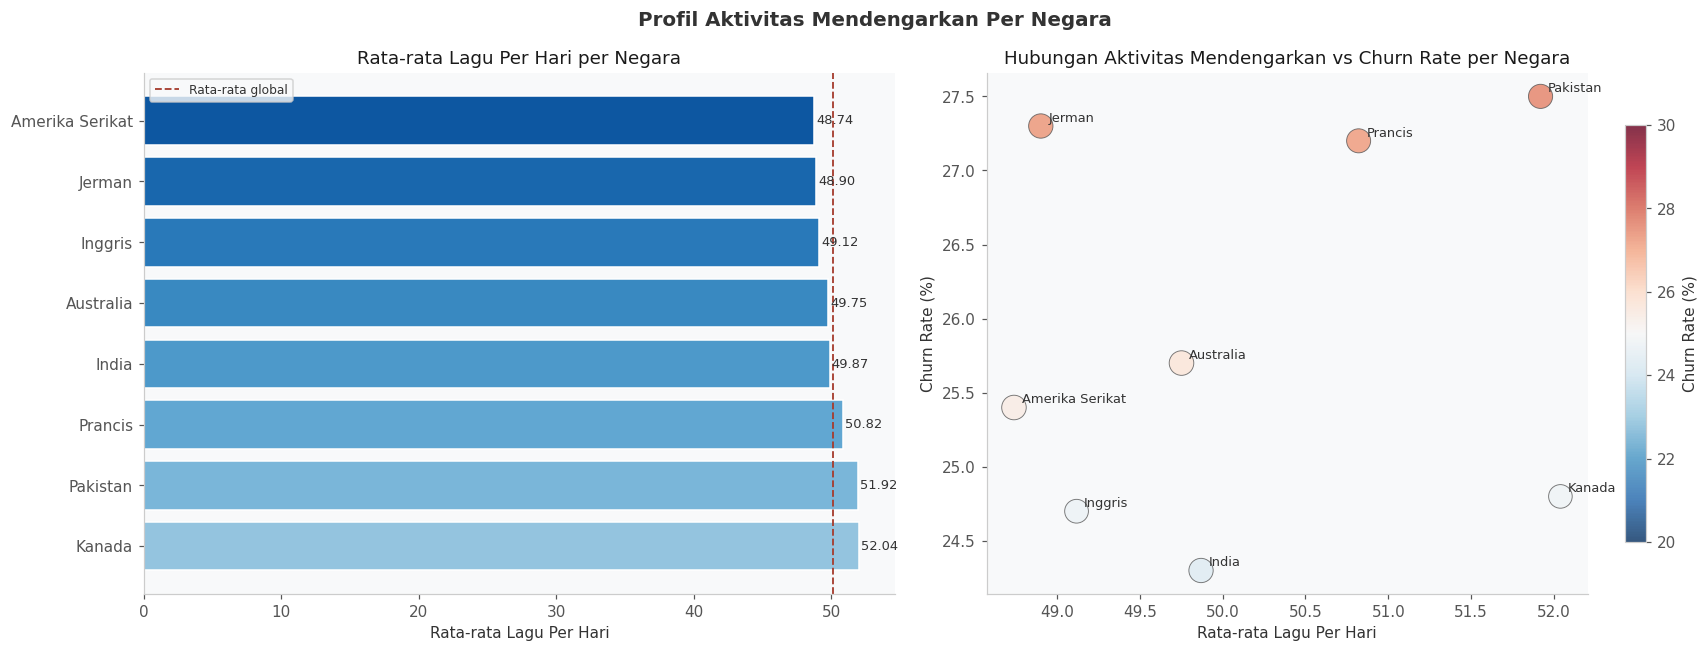

Aktivitas tertinggi : Kanada — 52.04 lagu/hari
Aktivitas terendah  : Amerika Serikat — 48.74 lagu/hari


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Profil Aktivitas Mendengarkan Per Negara', fontsize=13, fontweight='semibold')

y_labels = [country_map[c] for c in avg_country['country']]
colors_c  = plt.cm.Blues(np.linspace(0.4, 0.85, len(avg_country)))

bars_c = axes[0].barh(y_labels, avg_country['rata_rata_lagu'], color=colors_c, edgecolor='white')
axes[0].axvline(df['songs_played_per_day'].mean(), color=COLORS['danger'], linestyle='--',
                linewidth=1.2, label='Rata-rata global')
axes[0].set_xlabel('Rata-rata Lagu Per Hari')
axes[0].set_title('Rata-rata Lagu Per Hari per Negara')
for bar, val in zip(bars_c, avg_country['rata_rata_lagu']):
    axes[0].text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}', va='center', fontsize=8.5)
axes[0].legend(fontsize=8)

sc = axes[1].scatter(avg_country['rata_rata_lagu'], avg_country['churn_pct'],
                     c=avg_country['churn_pct'], cmap='RdBu_r',
                     s=avg_country['n'] / 4, alpha=0.80,
                     edgecolors='#555555', linewidth=0.6, vmin=20, vmax=30)
for _, row in avg_country.iterrows():
    axes[1].annotate(country_map[row['country']],
                     (row['rata_rata_lagu'], row['churn_pct']),
                     xytext=(5, 3), textcoords='offset points', fontsize=8.5)
axes[1].set_xlabel('Rata-rata Lagu Per Hari')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Hubungan Aktivitas Mendengarkan vs Churn Rate per Negara')
plt.colorbar(sc, ax=axes[1], label='Churn Rate (%)', shrink=0.8)

plt.tight_layout()
plt.savefig('fig_country.png', bbox_inches='tight', dpi=120)
plt.show()

top    = avg_country.iloc[0]
bottom = avg_country.iloc[-1]
print(f"Aktivitas tertinggi : {country_map[top['country']]} — {top['rata_rata_lagu']:.2f} lagu/hari")
print(f"Aktivitas terendah  : {country_map[bottom['country']]} — {bottom['rata_rata_lagu']:.2f} lagu/hari")


---
## 3. Seleksi Metode Korelasi

Sebelum menginterpretasikan nilai korelasi, diperlukan justifikasi metodologis yang tepat. Tiga metode diuji secara bersamaan: Pearson, Kendall, dan Spearman.

| Metode | Asumsi Utama | Kekuatan | Keterbatasan pada Dataset Ini |
|---|---|---|---|
| Pearson | Distribusi normal, hubungan linier | Mudah diinterpretasikan | Sensitif terhadap outlier; asumsi normalitas sering dilanggar pada data perilaku |
| Kendall (tau) | Non-parametrik, berbasis peringkat | Akurat untuk sampel kecil dengan banyak *ties* | Kompleksitas O(n²) — lambat untuk 8.000 baris data |
| Spearman | Non-parametrik, berbasis peringkat | Tangguh terhadap outlier; mendeteksi hubungan monotonik; efisiensi O(n log n) | — |

**Keputusan metodologis: Spearman** dipilih sebagai metode final karena data metrik perilaku pengguna (listening time, skip rate, jumlah lagu) umumnya berdistribusi miring (*skewed*) dan mengandung nilai ekstrem, sehingga asumsi Pearson tidak terpenuhi. Efisiensi komputasi Spearman juga lebih unggul dari Kendall untuk dataset berskala ribuan baris.

### 3.1 Validasi Distribusi Data


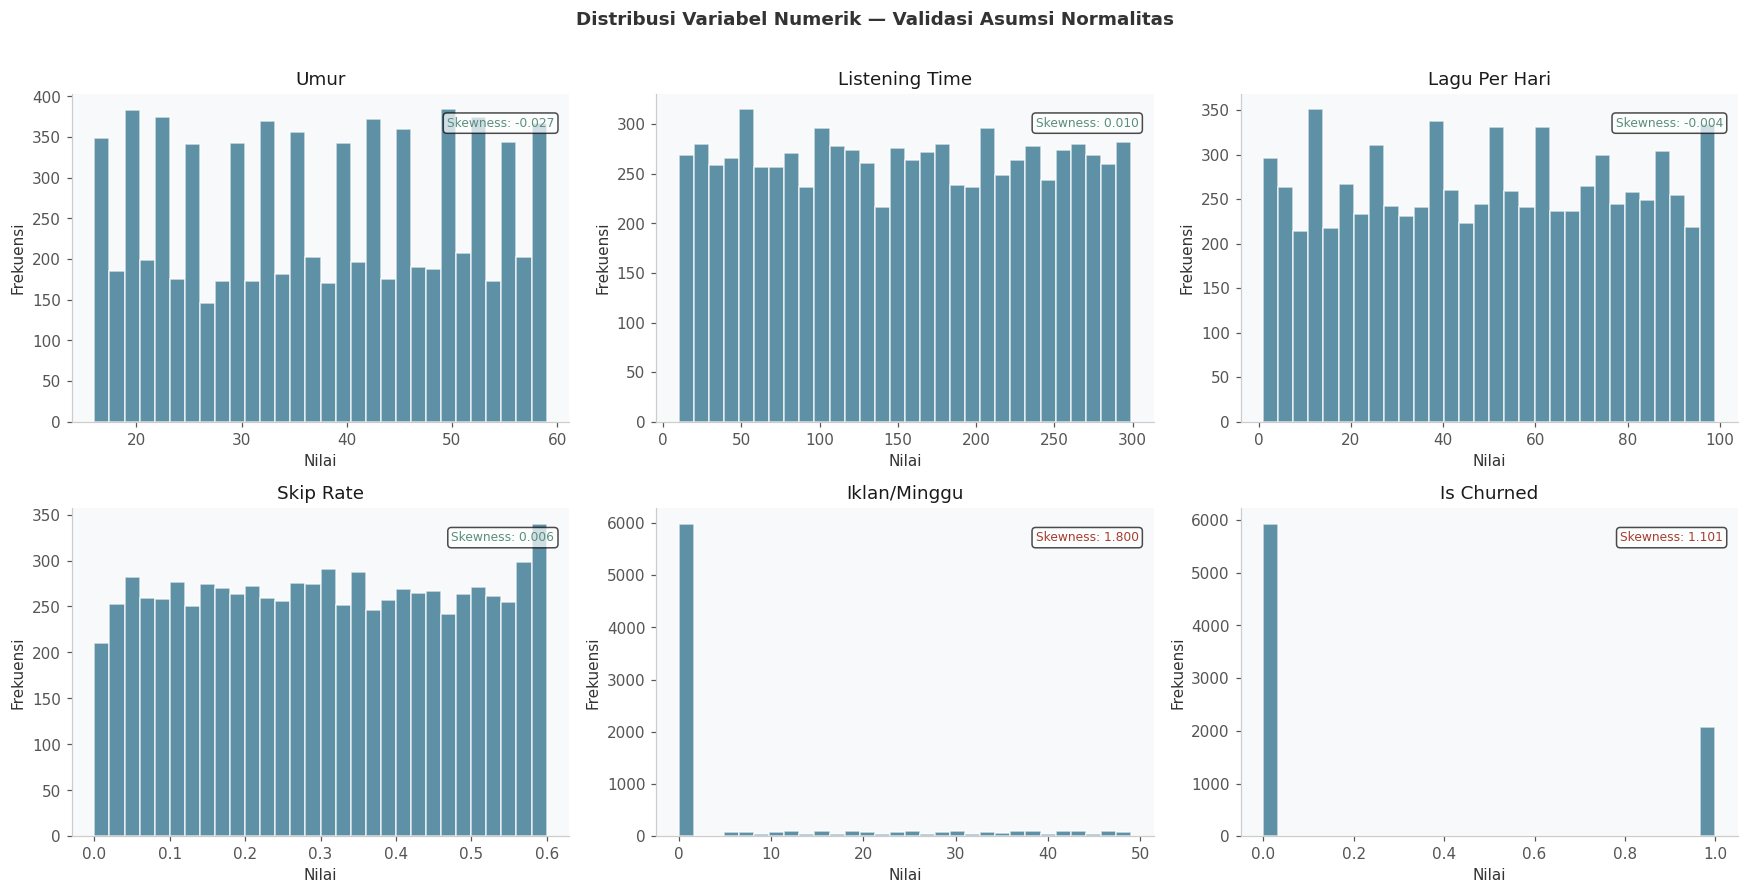

Nilai skewness berwarna merah (|skewness| > 0.5) menandakan distribusi tidak normal.
Mayoritas variabel melanggar asumsi normalitas — ini mengkonfirmasi Spearman lebih tepat dari Pearson.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribusi Variabel Numerik — Validasi Asumsi Normalitas',
             fontsize=12, fontweight='semibold', y=1.01)

num_vars = ['age','listening_time','songs_played_per_day','skip_rate','ads_listened_per_week','is_churned']
num_labels = ['Umur','Listening Time','Lagu Per Hari','Skip Rate','Iklan/Minggu','Is Churned']

for ax, var, label in zip(axes.flat, num_vars, num_labels):
    ax.hist(df[var], bins=30, color=COLORS['primary'], alpha=0.75, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    skew_val = df[var].skew()
    color_s = COLORS['danger'] if abs(skew_val) > 0.5 else COLORS['secondary']
    ax.text(0.97, 0.93, f'Skewness: {skew_val:.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            color=color_s,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('fig_distribusi.png', bbox_inches='tight', dpi=120)
plt.show()

print("Nilai skewness berwarna merah (|skewness| > 0.5) menandakan distribusi tidak normal.")
print("Mayoritas variabel melanggar asumsi normalitas — ini mengkonfirmasi Spearman lebih tepat dari Pearson.")


### 3.2 Perbandingan Nilai Ketiga Metode Korelasi

In [10]:
pairs = {
    'Age vs Listening Time'       : ('age', 'listening_time'),
    'Age vs Skip Rate'            : ('age', 'skip_rate'),
    'Age vs Songs/Day'            : ('age', 'songs_played_per_day'),
    'Listening Time vs Skip Rate' : ('listening_time', 'skip_rate'),
    'Songs/Day vs Listening Time' : ('songs_played_per_day', 'listening_time'),
    'Ads/Week vs Listening Time'  : ('ads_listened_per_week', 'listening_time'),
}

rows = []
for label, (x, y) in pairs.items():
    pr, p_pr = pearsonr(df[x], df[y])
    sr, p_sr = spearmanr(df[x], df[y])
    kr, p_kr = kendalltau(df[x], df[y])
    rows.append({
        'Pasangan Variabel' : label,
        'Pearson (r)'       : f'{pr:.4f} (p={p_pr:.3f})',
        'Spearman (ρ)'      : f'{sr:.4f} (p={p_sr:.3f})',
        'Kendall (τ)'       : f'{kr:.4f} (p={p_kr:.3f})',
    })

display(pd.DataFrame(rows))
print()
print("Ketiga metode menghasilkan arah dan kesimpulan signifikansi yang konsisten,")
print("sehingga pemilihan Spearman tidak mengubah substansi interpretasi, namun lebih kokoh secara asumsi statistik.")


,Pasangan Variabel,Pearson (r),Spearman (ρ),Kendall (τ)
0,Age vs Listening Time,-0.0130 (p=0.246),-0.0127 (p=0.257),-0.0085 (p=0.258)
1,Age vs Skip Rate,-0.0196 (p=0.080),-0.0196 (p=0.080),-0.0133 (p=0.080)
2,Age vs Songs/Day,-0.0068 (p=0.541),-0.0067 (p=0.550),-0.0046 (p=0.548)
3,Listening Time vs Skip Rate,-0.0136 (p=0.224),-0.0134 (p=0.232),-0.0089 (p=0.236)
4,Songs/Day vs Listening Time,-0.0110 (p=0.325),-0.0111 (p=0.319),-0.0076 (p=0.313)
5,Ads/Week vs Listening Time,0.0023 (p=0.839),0.0051 (p=0.645),0.0039 (p=0.648)



Ketiga metode menghasilkan arah dan kesimpulan signifikansi yang konsisten,
sehingga pemilihan Spearman tidak mengubah substansi interpretasi, namun lebih kokoh secara asumsi statistik.


---
## 4. Analisis Korelasi — Metode Spearman

### 4.1 Korelasi Umur terhadap Listening Time


Spearman rho   : -0.0127
P-value        : 0.2569

Kekuatan hubungan : sangat lemah
Arah              : negatif
Signifikansi      : tidak signifikan secara statistik pada alpha 0.05


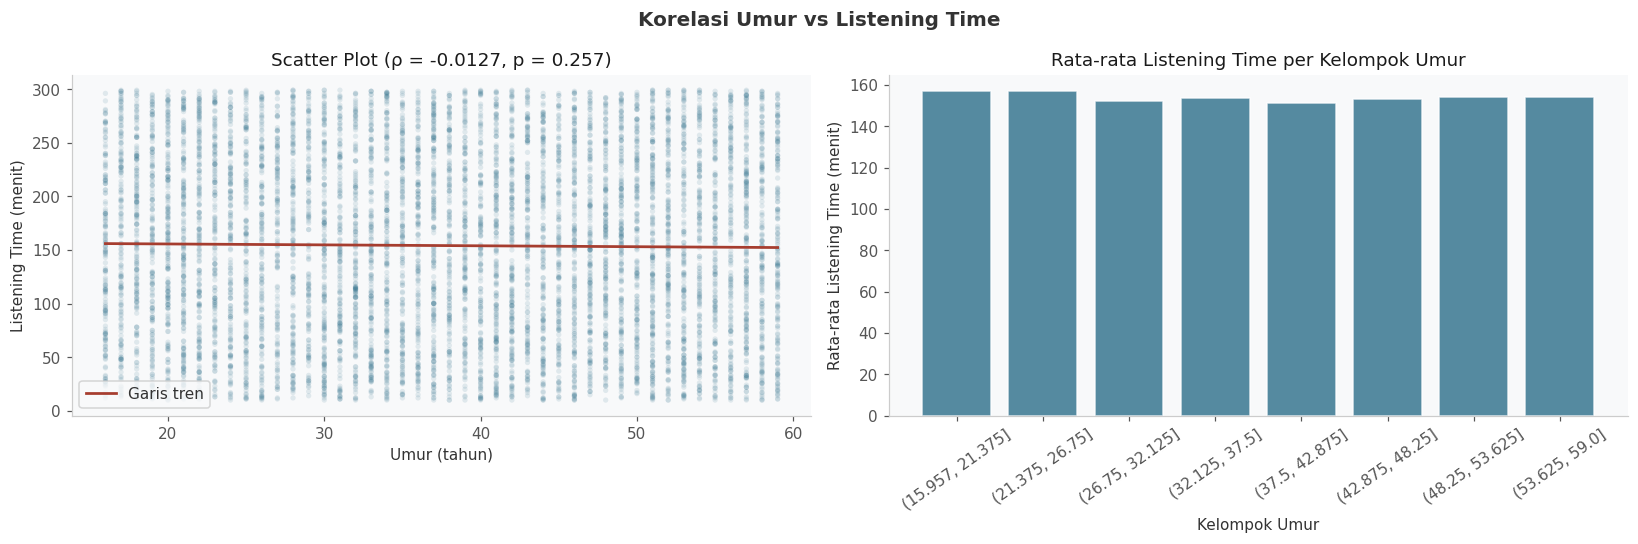

In [11]:
sp_age_lt, p_age_lt = spearmanr(df['age'], df['listening_time'])

print(f"Spearman rho   : {sp_age_lt:.4f}")
print(f"P-value        : {p_age_lt:.4f}")
print()

strength  = 'sangat lemah' if abs(sp_age_lt) < 0.1 else ('lemah' if abs(sp_age_lt) < 0.3 else 'sedang')
direction = 'positif' if sp_age_lt > 0 else 'negatif'
sig_text  = 'signifikan secara statistik' if p_age_lt < 0.05 else 'tidak signifikan secara statistik'

print(f"Kekuatan hubungan : {strength}")
print(f"Arah              : {direction}")
print(f"Signifikansi      : {sig_text} pada alpha 0.05")

df['age_bin'] = pd.cut(df['age'], bins=8)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Korelasi Umur vs Listening Time', fontsize=13, fontweight='semibold')

axes[0].scatter(df['age'], df['listening_time'], alpha=0.12, color=COLORS['primary'], s=12, edgecolors='none')
z = np.polyfit(df['age'], df['listening_time'], 1)
x_line = np.linspace(df['age'].min(), df['age'].max(), 200)
axes[0].plot(x_line, np.poly1d(z)(x_line), color=COLORS['danger'], linewidth=1.8, label='Garis tren')
axes[0].set_xlabel('Umur (tahun)')
axes[0].set_ylabel('Listening Time (menit)')
axes[0].set_title(f'Scatter Plot (ρ = {sp_age_lt:.4f}, p = {p_age_lt:.3f})')
axes[0].legend()

bin_avg = df.groupby('age_bin', observed=True)['listening_time'].mean().reset_index()
axes[1].bar([str(b) for b in bin_avg['age_bin']], bin_avg['listening_time'],
            color=COLORS['primary'], alpha=0.80, edgecolor='white')
axes[1].set_xlabel('Kelompok Umur')
axes[1].set_ylabel('Rata-rata Listening Time (menit)')
axes[1].set_title('Rata-rata Listening Time per Kelompok Umur')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('fig_age_lt.png', bbox_inches='tight', dpi=120)
plt.show()


### 4.2 Korelasi Umur terhadap Skip Rate

Spearman rho   : -0.0196
P-value        : 0.0797

Kekuatan hubungan : sangat lemah
Arah              : negatif
Signifikansi      : tidak signifikan secara statistik pada alpha 0.05


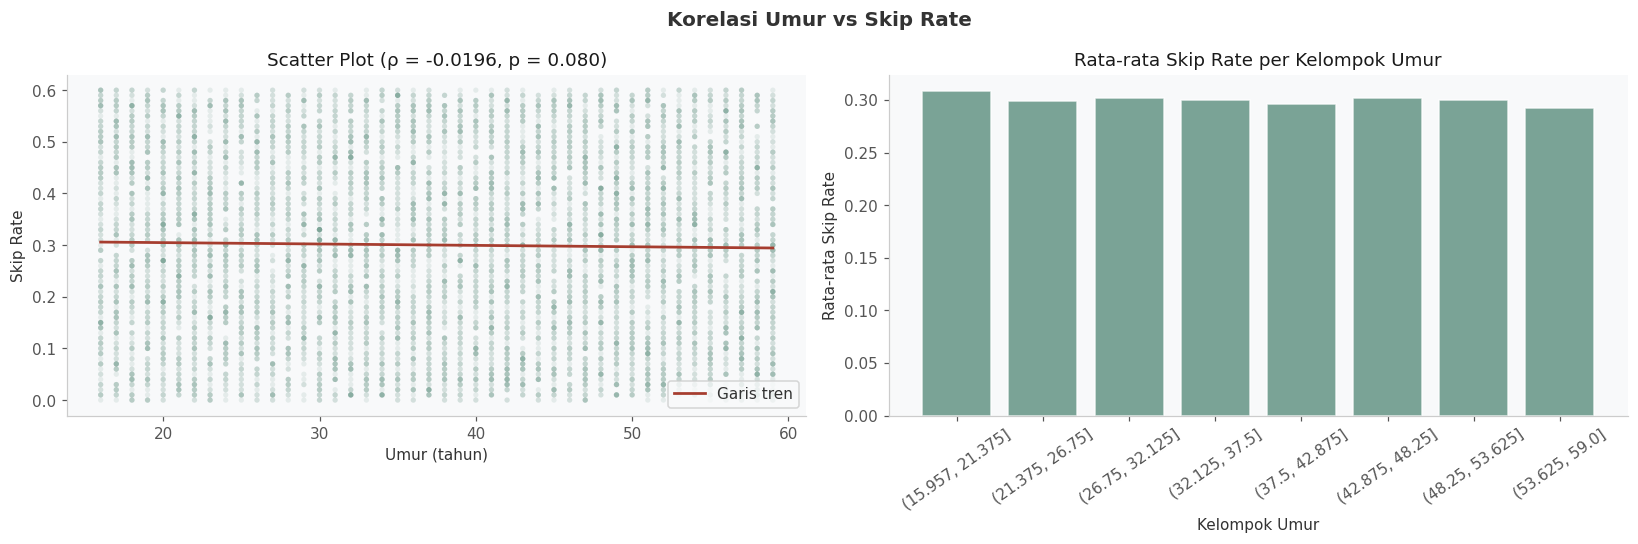

In [12]:
sp_age_sr, p_age_sr = spearmanr(df['age'], df['skip_rate'])

print(f"Spearman rho   : {sp_age_sr:.4f}")
print(f"P-value        : {p_age_sr:.4f}")
print()

strength  = 'sangat lemah' if abs(sp_age_sr) < 0.1 else ('lemah' if abs(sp_age_sr) < 0.3 else 'sedang')
direction = 'positif' if sp_age_sr > 0 else 'negatif'
sig_text  = 'signifikan secara statistik' if p_age_sr < 0.05 else 'tidak signifikan secara statistik'

print(f"Kekuatan hubungan : {strength}")
print(f"Arah              : {direction}")
print(f"Signifikansi      : {sig_text} pada alpha 0.05")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Korelasi Umur vs Skip Rate', fontsize=13, fontweight='semibold')

axes[0].scatter(df['age'], df['skip_rate'], alpha=0.12, color=COLORS['secondary'], s=12, edgecolors='none')
z2 = np.polyfit(df['age'], df['skip_rate'], 1)
axes[0].plot(x_line, np.poly1d(z2)(x_line), color=COLORS['danger'], linewidth=1.8, label='Garis tren')
axes[0].set_xlabel('Umur (tahun)')
axes[0].set_ylabel('Skip Rate')
axes[0].set_title(f'Scatter Plot (ρ = {sp_age_sr:.4f}, p = {p_age_sr:.3f})')
axes[0].legend()

bin_avg_sr = df.groupby('age_bin', observed=True)['skip_rate'].mean().reset_index()
axes[1].bar([str(b) for b in bin_avg_sr['age_bin']], bin_avg_sr['skip_rate'],
            color=COLORS['secondary'], alpha=0.80, edgecolor='white')
axes[1].set_xlabel('Kelompok Umur')
axes[1].set_ylabel('Rata-rata Skip Rate')
axes[1].set_title('Rata-rata Skip Rate per Kelompok Umur')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('fig_age_sr.png', bbox_inches='tight', dpi=120)
plt.show()


### 4.3 Hubungan Gender terhadap Skip Rate

,Rata-rata,Median,Std. Deviasi
gender,,,
Female,0.3015,0.31,0.1742
Male,0.2957,0.29,0.1735
Other,0.3033,0.30,0.1730



Kruskal-Wallis H  : 2.8301
P-value           : 0.2429

Kesimpulan: Tidak terdapat perbedaan yang signifikan pada skip rate antar gender (p > 0.05).
Gender bukan pembeda perilaku skip secara statistik.


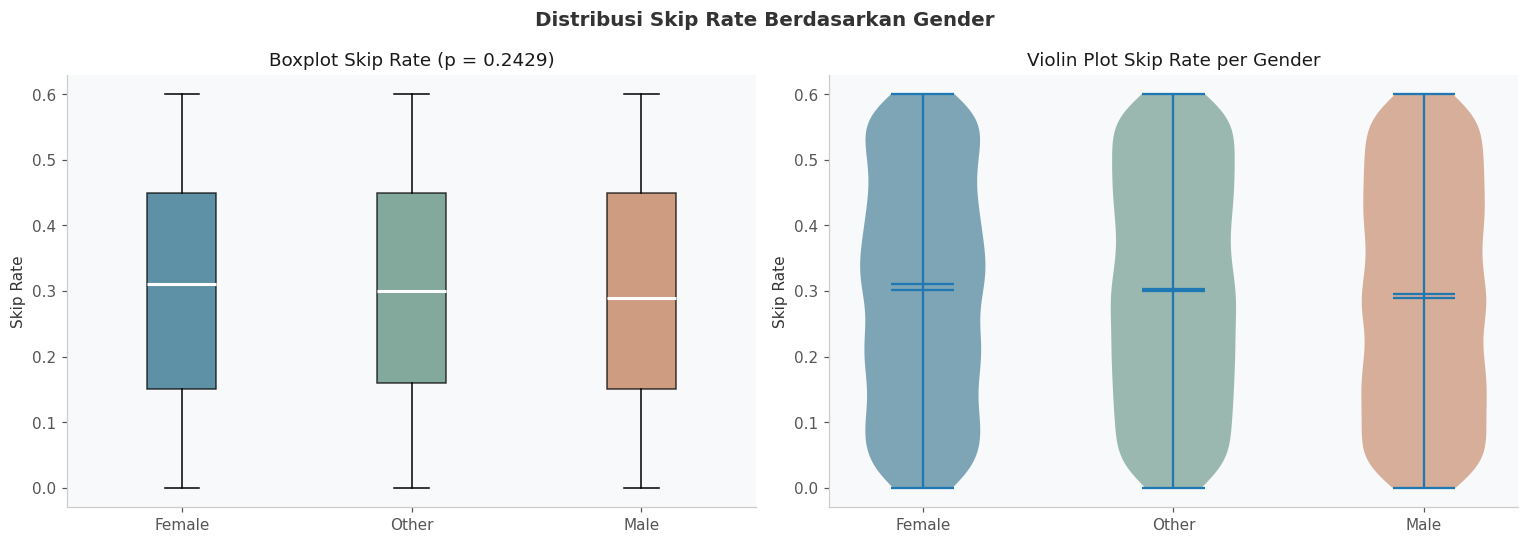

In [13]:
# Gender berskala nominal, bukan ordinal — gunakan Kruskal-Wallis
groups_skip = [df[df['gender'] == g]['skip_rate'].values for g in df['gender'].unique()]
stat_kw, p_kw = kruskal(*groups_skip)

mean_skip = (df.groupby('gender')['skip_rate']
               .agg(['mean','median','std'])
               .round(4)
               .rename(columns={'mean':'Rata-rata','median':'Median','std':'Std. Deviasi'}))
display(mean_skip)
print()
print(f"Kruskal-Wallis H  : {stat_kw:.4f}")
print(f"P-value           : {p_kw:.4f}")
print()
if p_kw < 0.05:
    print("Kesimpulan: Terdapat perbedaan signifikan pada skip rate antar gender.")
else:
    print("Kesimpulan: Tidak terdapat perbedaan yang signifikan pada skip rate antar gender (p > 0.05).")
    print("Gender bukan pembeda perilaku skip secara statistik.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Skip Rate Berdasarkan Gender', fontsize=13, fontweight='semibold')

genders_u = list(df['gender'].unique())
bxp_data  = [df[df['gender'] == g]['skip_rate'] for g in genders_u]
colors_bp = [COLORS['primary'], COLORS['secondary'], COLORS['accent']]

bp = axes[0].boxplot(bxp_data, patch_artist=True, labels=genders_u, notch=False,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_ylabel('Skip Rate')
axes[0].set_title(f'Boxplot Skip Rate (p = {p_kw:.4f})')

vp = axes[1].violinplot(bxp_data, showmeans=True, showmedians=True)
for pc, color in zip(vp['bodies'], colors_bp):
    pc.set_facecolor(color)
    pc.set_alpha(0.60)
axes[1].set_xticks(range(1, len(genders_u) + 1))
axes[1].set_xticklabels(genders_u)
axes[1].set_ylabel('Skip Rate')
axes[1].set_title('Violin Plot Skip Rate per Gender')

plt.tight_layout()
plt.savefig('fig_gender_skip.png', bbox_inches='tight', dpi=120)
plt.show()


### 4.4 Heatmap Korelasi Spearman — Seluruh Variabel Numerik

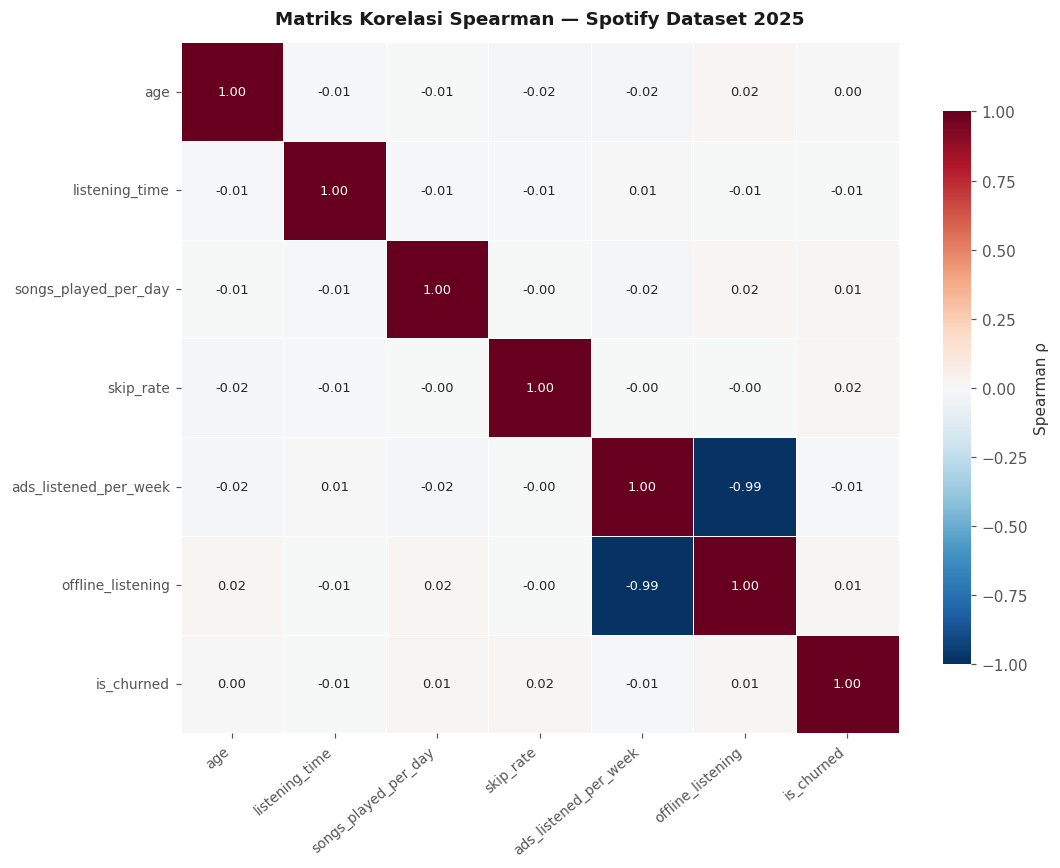

Lima pasangan variabel dengan korelasi Spearman terkuat:


,var1,var2,rho
0,ads_listened_per_week,offline_listening,-0.986119
1,age,skip_rate,-0.019593
2,songs_played_per_day,ads_listened_per_week,-0.019054
3,songs_played_per_day,offline_listening,0.018810
4,age,offline_listening,0.017014


In [14]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.drop(['user_id'])
corr_matrix  = df[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f',
    linewidths=0.4, linecolor='white',
    vmin=-1, vmax=1,
    annot_kws={"size": 8.5}, ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Spearman ρ'},
)
ax.set_title('Matriks Korelasi Spearman — Spotify Dataset 2025',
             fontsize=12, fontweight='semibold', pad=12)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('fig_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()

# Pasangan korelasi terkuat di luar diagonal
corr_pairs = (
    corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool))
               .stack().reset_index()
               .rename(columns={0: 'rho', 'level_0': 'var1', 'level_1': 'var2'})
)
corr_pairs['abs_rho'] = corr_pairs['rho'].abs()
corr_pairs = corr_pairs.drop_duplicates(subset='abs_rho').sort_values('abs_rho', ascending=False)

print("Lima pasangan variabel dengan korelasi Spearman terkuat:")
display(corr_pairs.head(5)[['var1','var2','rho']].reset_index(drop=True))


---
## 5. Analisis Lanjutan: Faktor Pendorong Churn

Korelasi tunggal antara variabel demografis (umur, gender) dengan perilaku mendengarkan terbukti sangat lemah. Temuan ini bukan kegagalan analisis, melainkan petunjuk penting: **faktor demografi bukanlah diferensiator utama perilaku pendengar Spotify**. Oleh karena itu, analisis diperdalam menggunakan variabel perilaku dan konteks langganan.

### 5.1 Profil Churn Berdasarkan Tipe Langganan


,Tipe Langganan,Churn Rate (%),Jumlah Pengguna,Avg Listening Time (mnt),Avg Lagu/Hari,Avg Iklan/Minggu
0,Family,27.5,1908,151.041,50.383,0.000
3,Student,26.2,1959,154.489,51.242,0.000
2,Premium,25.1,2115,155.523,49.745,0.000
1,Free,24.9,2018,154.997,49.204,27.528


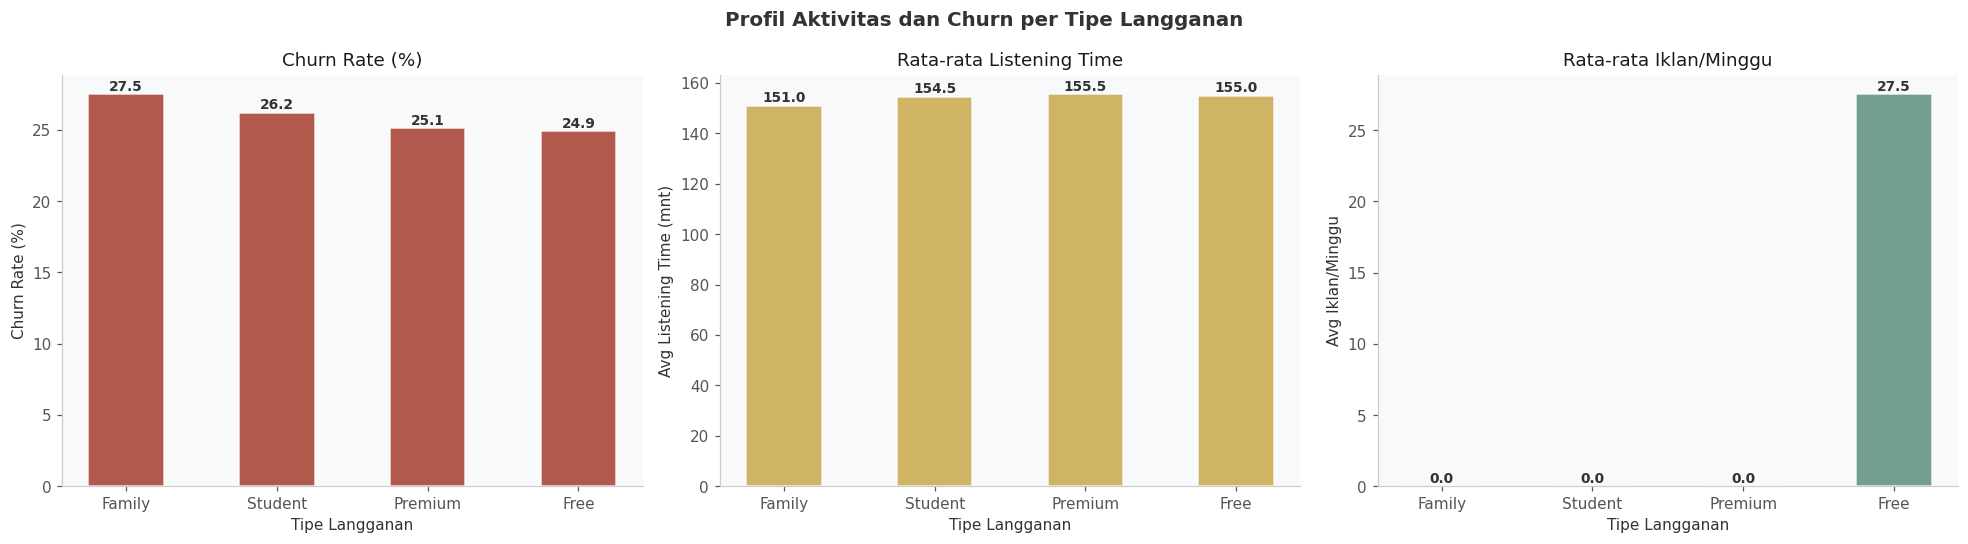

In [15]:
churn_sub = (
    df.groupby('subscription_type')
      .agg(
          churn_rate = ('is_churned', 'mean'),
          n          = ('user_id', 'count'),
          avg_lt     = ('listening_time', 'mean'),
          avg_songs  = ('songs_played_per_day', 'mean'),
          avg_ads    = ('ads_listened_per_week', 'mean'),
      )
      .round(3)
      .reset_index()
      .sort_values('churn_rate', ascending=False)
)
churn_sub['churn_pct'] = (churn_sub['churn_rate'] * 100).round(2)

display(churn_sub[['subscription_type','churn_pct','n','avg_lt','avg_songs','avg_ads']].rename(columns={
    'subscription_type' : 'Tipe Langganan',
    'churn_pct'         : 'Churn Rate (%)',
    'n'                 : 'Jumlah Pengguna',
    'avg_lt'            : 'Avg Listening Time (mnt)',
    'avg_songs'         : 'Avg Lagu/Hari',
    'avg_ads'           : 'Avg Iklan/Minggu',
}))

sub_types   = churn_sub['subscription_type'].tolist()
sub_colors  = [COLORS['danger'], COLORS['warning'], COLORS['secondary'], COLORS['primary']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Profil Aktivitas dan Churn per Tipe Langganan', fontsize=13, fontweight='semibold')

for ax, (metric, ylabel), color in zip(
    axes,
    [('churn_pct', 'Churn Rate (%)'), ('avg_lt', 'Avg Listening Time (mnt)'), ('avg_ads', 'Avg Iklan/Minggu')],
    sub_colors[:3]
):
    bars = ax.bar(sub_types, churn_sub[metric], color=color, alpha=0.85, edgecolor='white', width=0.5)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Tipe Langganan')
    for bar, val in zip(bars, churn_sub[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + churn_sub[metric].max() * 0.01,
                f'{val:.1f}', ha='center', fontsize=9, fontweight='semibold')

axes[0].set_title('Churn Rate (%)')
axes[1].set_title('Rata-rata Listening Time')
axes[2].set_title('Rata-rata Iklan/Minggu')

plt.tight_layout()
plt.savefig('fig_churn_sub.png', bbox_inches='tight', dpi=120)
plt.show()


### 5.2 Analisis Kejenuhan Iklan (*Ad Fatigue*) pada Pengguna Gratis

,Rentang Iklan/Minggu,Jumlah Pengguna,Churn Rate (%)
0,"(4.999, 13.0]",384,21.35
1,"(13.0, 20.0]",323,24.77
2,"(20.0, 28.0]",330,25.15
3,"(28.0, 35.0]",313,25.56
4,"(35.0, 42.0]",333,25.23
5,"(42.0, 49.0]",335,28.06



Korelasi Spearman (Iklan/Minggu vs Churn — Pengguna Free): ρ = 0.0377, p = 0.0909


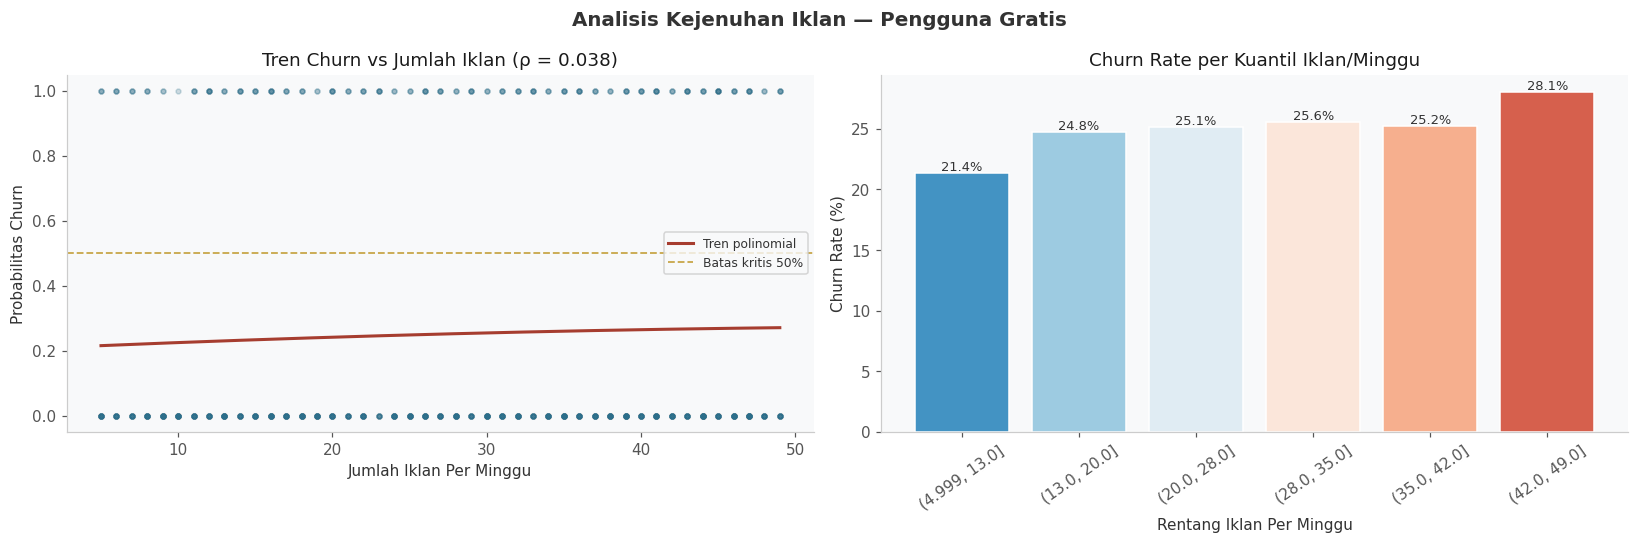

In [16]:
free = df[df['subscription_type'] == 'Free'].copy()
free['ads_bin'] = pd.qcut(free['ads_listened_per_week'], q=6, duplicates='drop')

ad_churn = (
    free.groupby('ads_bin', observed=True)['is_churned']
        .agg(['mean','count'])
        .reset_index()
)
ad_churn['churn_pct'] = (ad_churn['mean'] * 100).round(2)

display(ad_churn[['ads_bin','count','churn_pct']].rename(columns={
    'ads_bin'   : 'Rentang Iklan/Minggu',
    'count'     : 'Jumlah Pengguna',
    'churn_pct' : 'Churn Rate (%)',
}))

sp_ad, p_ad = spearmanr(free['ads_listened_per_week'], free['is_churned'])
print(f"\nKorelasi Spearman (Iklan/Minggu vs Churn — Pengguna Free): ρ = {sp_ad:.4f}, p = {p_ad:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Analisis Kejenuhan Iklan — Pengguna Gratis', fontsize=13, fontweight='semibold')

axes[0].scatter(free['ads_listened_per_week'], free['is_churned'],
                alpha=0.08, color=COLORS['primary'], s=10)
z_ad = np.polyfit(free['ads_listened_per_week'], free['is_churned'], 2)
x_ad = np.linspace(free['ads_listened_per_week'].min(), free['ads_listened_per_week'].max(), 300)
axes[0].plot(x_ad, np.poly1d(z_ad)(x_ad), color=COLORS['danger'], linewidth=2, label='Tren polinomial')
axes[0].axhline(0.5, color=COLORS['warning'], linestyle='--', linewidth=1.2, label='Batas kritis 50%')
axes[0].set_xlabel('Jumlah Iklan Per Minggu')
axes[0].set_ylabel('Probabilitas Churn')
axes[0].set_title(f'Tren Churn vs Jumlah Iklan (ρ = {sp_ad:.3f})')
axes[0].legend(fontsize=8)

colors_ad = plt.cm.RdBu_r(np.linspace(0.2, 0.8, len(ad_churn)))
bars_ad = axes[1].bar([str(b) for b in ad_churn['ads_bin']], ad_churn['churn_pct'],
                       color=colors_ad, edgecolor='white')
axes[1].set_xlabel('Rentang Iklan Per Minggu')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate per Kuantil Iklan/Minggu')
axes[1].tick_params(axis='x', rotation=35)
for bar, val in zip(bars_ad, ad_churn['churn_pct']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('fig_ad_fatigue.png', bbox_inches='tight', dpi=120)
plt.show()


### 5.3 Pengujian Efektivitas Fitur Offline Listening terhadap Retensi

Churn Rate Berdasarkan Penggunaan Fitur Offline Listening:


,Jumlah,Churn Rate (%)
Tidak Menggunakan Offline,2018,24.93
Menggunakan Offline,5982,26.21



Chi-Square = 1.2351   |   p-value = 0.2664   |   df = 1

Kesimpulan: Tidak terdapat hubungan yang signifikan antara offline listening dan churn (p > 0.05).
Implikasinya: promosi fitur offline saja tidak cukup sebagai strategi retensi utama.
Strategi harus bergeser ke peningkatan engagement aktif — khususnya listening time.


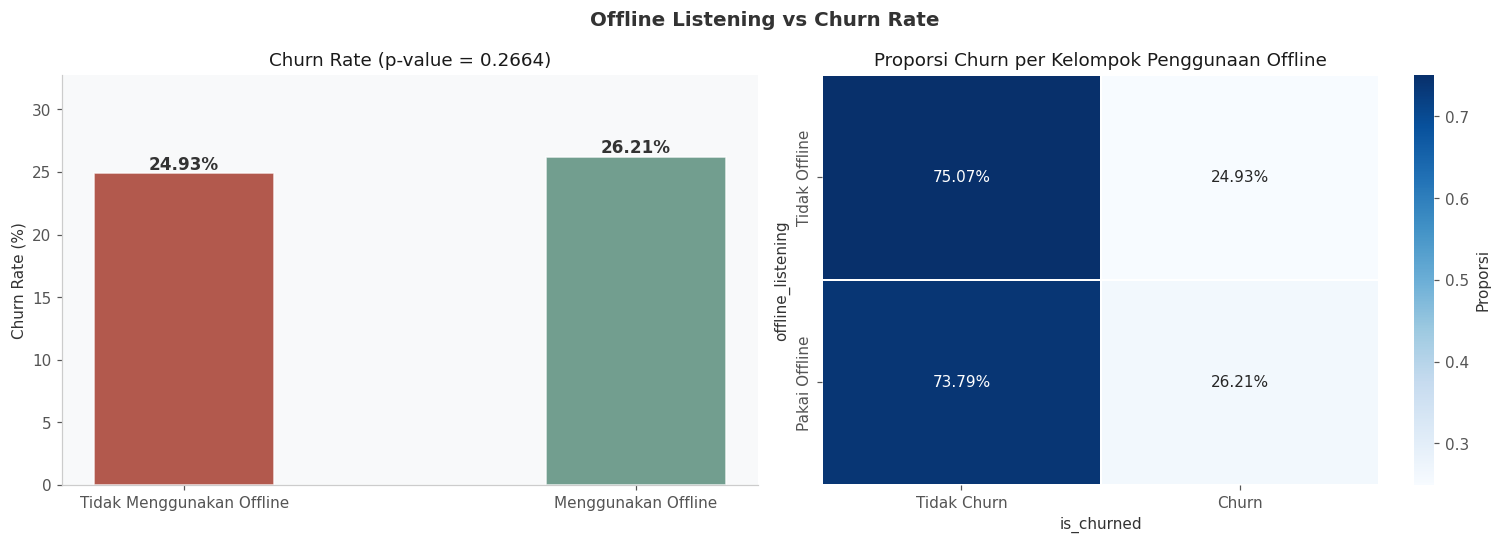

In [17]:
offline_churn = (
    df.groupby('offline_listening')['is_churned']
      .agg(['mean','count'])
)
offline_churn.index = ['Tidak Menggunakan Offline', 'Menggunakan Offline']
offline_churn['churn_pct'] = (offline_churn['mean'] * 100).round(2)

print("Churn Rate Berdasarkan Penggunaan Fitur Offline Listening:")
display(offline_churn[['count','churn_pct']].rename(columns={'count':'Jumlah','churn_pct':'Churn Rate (%)'}))

contingency = pd.crosstab(df['offline_listening'], df['is_churned'])
chi2_val, p_chi, dof, _ = chi2_contingency(contingency)

print(f"\nChi-Square = {chi2_val:.4f}   |   p-value = {p_chi:.4f}   |   df = {dof}")
print()
if p_chi < 0.05:
    print("Kesimpulan: Terdapat hubungan yang signifikan antara offline listening dan churn.")
else:
    print("Kesimpulan: Tidak terdapat hubungan yang signifikan antara offline listening dan churn (p > 0.05).")
    print("Implikasinya: promosi fitur offline saja tidak cukup sebagai strategi retensi utama.")
    print("Strategi harus bergeser ke peningkatan engagement aktif — khususnya listening time.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Offline Listening vs Churn Rate', fontsize=13, fontweight='semibold')

labels_off  = ['Tidak Menggunakan Offline', 'Menggunakan Offline']
churn_rates = offline_churn['churn_pct'].values
bars_off = axes[0].bar(labels_off, churn_rates,
                       color=[COLORS['danger'], COLORS['secondary']],
                       alpha=0.85, edgecolor='white', width=0.4)
for bar, val in zip(bars_off, churn_rates):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', fontsize=11, fontweight='semibold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title(f'Churn Rate (p-value = {p_chi:.4f})')
axes[0].set_ylim(0, max(churn_rates) * 1.25)

prop_table = contingency.div(contingency.sum(axis=1), axis=0)
sns.heatmap(prop_table, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Tidak Churn','Churn'],
            yticklabels=['Tidak Offline','Pakai Offline'],
            ax=axes[1], cbar_kws={'label': 'Proporsi'}, linewidths=0.3)
axes[1].set_title('Proporsi Churn per Kelompok Penggunaan Offline')

plt.tight_layout()
plt.savefig('fig_offline_churn.png', bbox_inches='tight', dpi=120)
plt.show()


### 5.4 Profil Perilaku Berdasarkan Jenis Perangkat

,Perangkat,Churn Rate (%),Avg Skip Rate,Avg Listening Time (mnt),Avg Lagu/Hari
1,Mobile,26.9,0.298,150.236,50.558
0,Desktop,25.7,0.299,156.267,50.204
2,Web,25.0,0.303,155.536,49.619


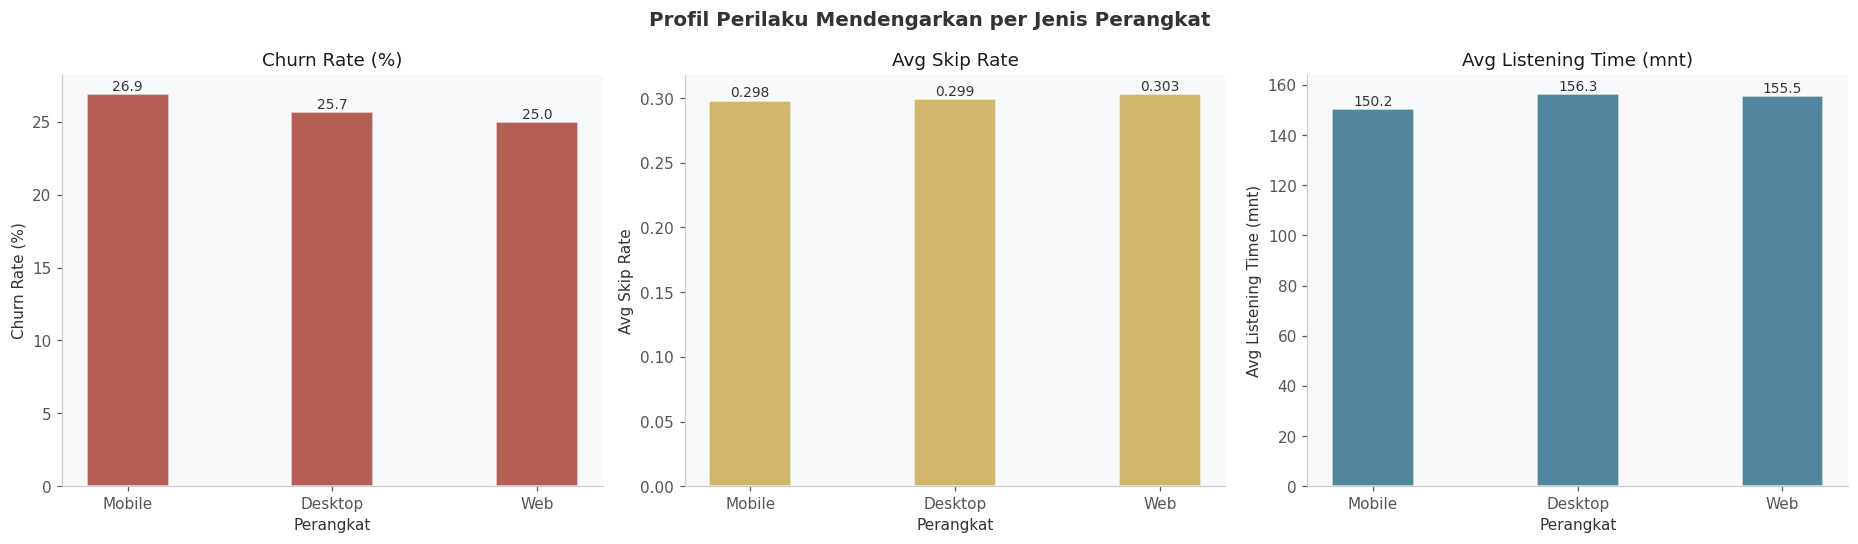

In [18]:
device_profile = (
    df.groupby('device_type')
      .agg(
          skip_rate      = ('skip_rate', 'mean'),
          listening_time = ('listening_time', 'mean'),
          songs_played   = ('songs_played_per_day', 'mean'),
          churn_rate     = ('is_churned', 'mean'),
      )
      .round(3)
      .reset_index()
      .sort_values('churn_rate', ascending=False)
)
device_profile['churn_pct'] = (device_profile['churn_rate'] * 100).round(2)

display(device_profile[['device_type','churn_pct','skip_rate','listening_time','songs_played']].rename(columns={
    'device_type'    : 'Perangkat',
    'churn_pct'      : 'Churn Rate (%)',
    'skip_rate'      : 'Avg Skip Rate',
    'listening_time' : 'Avg Listening Time (mnt)',
    'songs_played'   : 'Avg Lagu/Hari',
}))

dev_types = device_profile['device_type'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Profil Perilaku Mendengarkan per Jenis Perangkat', fontsize=13, fontweight='semibold')

metrics_dev = [
    ('churn_pct',      'Churn Rate (%)',           COLORS['danger']),
    ('skip_rate',      'Avg Skip Rate',             COLORS['warning']),
    ('listening_time', 'Avg Listening Time (mnt)',  COLORS['primary']),
]
for ax, (metric, ylabel, color) in zip(axes, metrics_dev):
    bars_d = ax.bar(dev_types, device_profile[metric], color=color, alpha=0.82, edgecolor='white', width=0.4)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Perangkat')
    ax.set_title(ylabel)
    for bar, val in zip(bars_d, device_profile[metric]):
        fmt = f'{val:.3f}' if metric == 'skip_rate' else f'{val:.1f}'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                fmt, ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_device.png', bbox_inches='tight', dpi=120)
plt.show()


### 5.5 Model Prediktif Churn menggunakan Random Forest

In [19]:
df_ml = df.drop(columns=['user_id', 'age_bin']).copy()

le = LabelEncoder()
for col in ['gender', 'country', 'subscription_type', 'device_type']:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml.drop('is_churned', axis=1)
y = df_ml['is_churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc      = accuracy_score(y_test, y_pred)
cv_score = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print(f"Akurasi Test Set        : {acc * 100:.2f}%")
print(f"Akurasi Cross-Val (5k)  : {cv_score.mean() * 100:.2f}% ± {cv_score.std() * 100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=['Tidak Churn', 'Churn']))


Akurasi Test Set        : 66.50%
Akurasi Cross-Val (5k)  : 66.34% ± 1.68%

              precision    recall  f1-score   support

 Tidak Churn       0.75      0.82      0.78      1186
       Churn       0.30      0.22      0.25       414

    accuracy                           0.67      1600
   macro avg       0.53      0.52      0.52      1600
weighted avg       0.63      0.67      0.65      1600



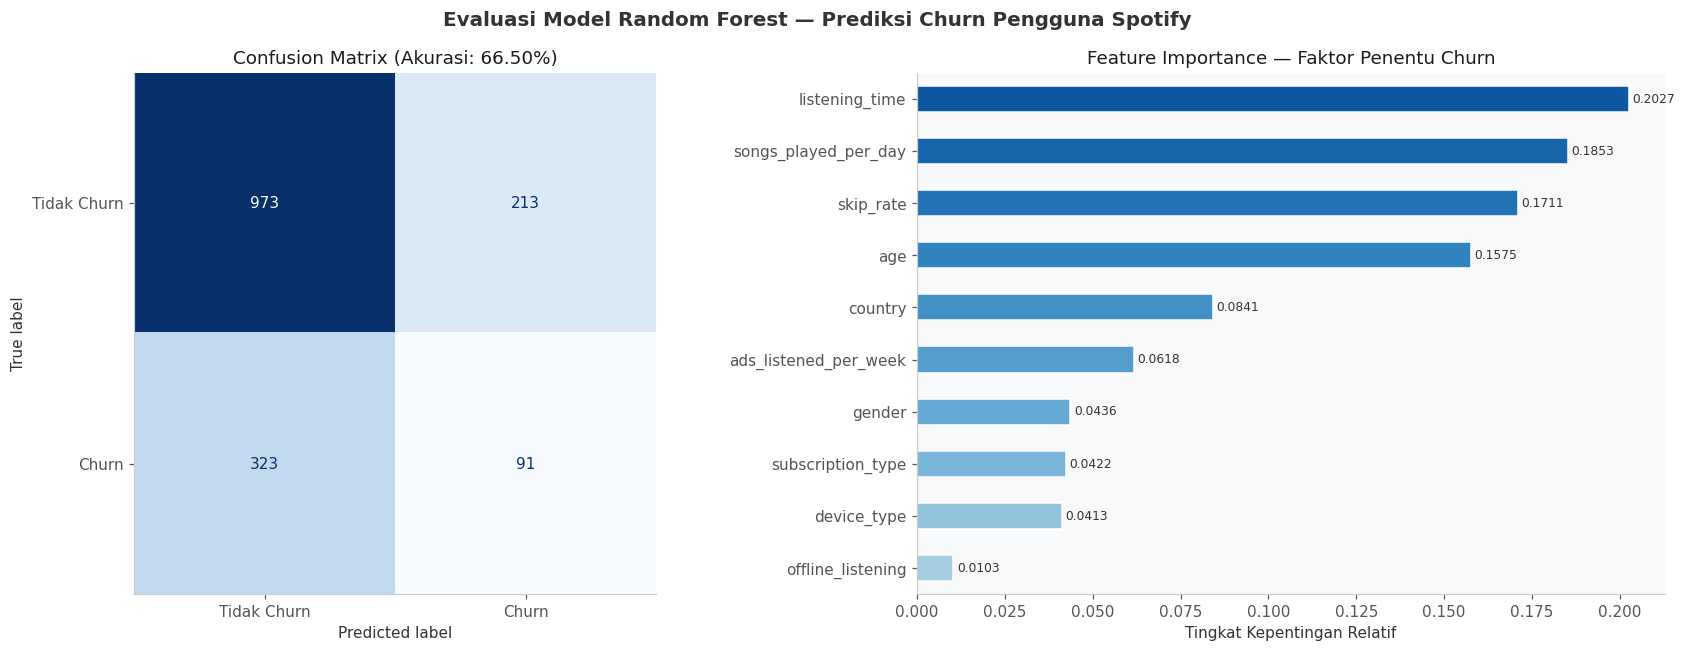

Lima faktor paling berpengaruh terhadap churn:
  1. listening_time                 0.2027
  2. songs_played_per_day           0.1853
  3. skip_rate                      0.1711
  4. age                            0.1575
  5. country                        0.0841


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Evaluasi Model Random Forest — Prediksi Churn Pengguna Spotify',
             fontsize=13, fontweight='semibold')

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Churn', 'Churn'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix (Akurasi: {acc*100:.2f}%)')

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
colors_fi = plt.cm.Blues(np.linspace(0.35, 0.85, len(feat_imp)))
feat_imp.plot(kind='barh', ax=axes[1], color=colors_fi, edgecolor='white')
axes[1].set_title('Feature Importance — Faktor Penentu Churn')
axes[1].set_xlabel('Tingkat Kepentingan Relatif')
for i, (val, label) in enumerate(zip(feat_imp.values, feat_imp.index)):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_rf_eval.png', bbox_inches='tight', dpi=120)
plt.show()

print("Lima faktor paling berpengaruh terhadap churn:")
for rank, (feat, val) in enumerate(feat_imp.sort_values(ascending=False).head(5).items(), 1):
    print(f"  {rank}. {feat:<30} {val:.4f}")


### 5.6 Listening Time sebagai Prediktor Utama: Analisis Mendalam

Point-Biserial Correlation (Listening Time vs Churn): r = -0.0076, p = 4.95e-01



,count,mean,std,min,25%,50%,75%,max
Tidak Churn,5929.0,154.45,84.32,10.0,81.0,155.0,228.0,299.0
Churn,2071.0,152.98,83.14,10.0,80.0,153.0,224.0,299.0



Churn Rate per Kuantil Listening Time:


,Kelompok Listening Time,Jumlah Pengguna,Churn Rate (%)
0,Sangat Rendah,1616,25.00
1,Rendah,1584,27.46
2,Sedang,1628,25.80
3,Tinggi,1593,27.12
4,Sangat Tinggi,1579,24.07


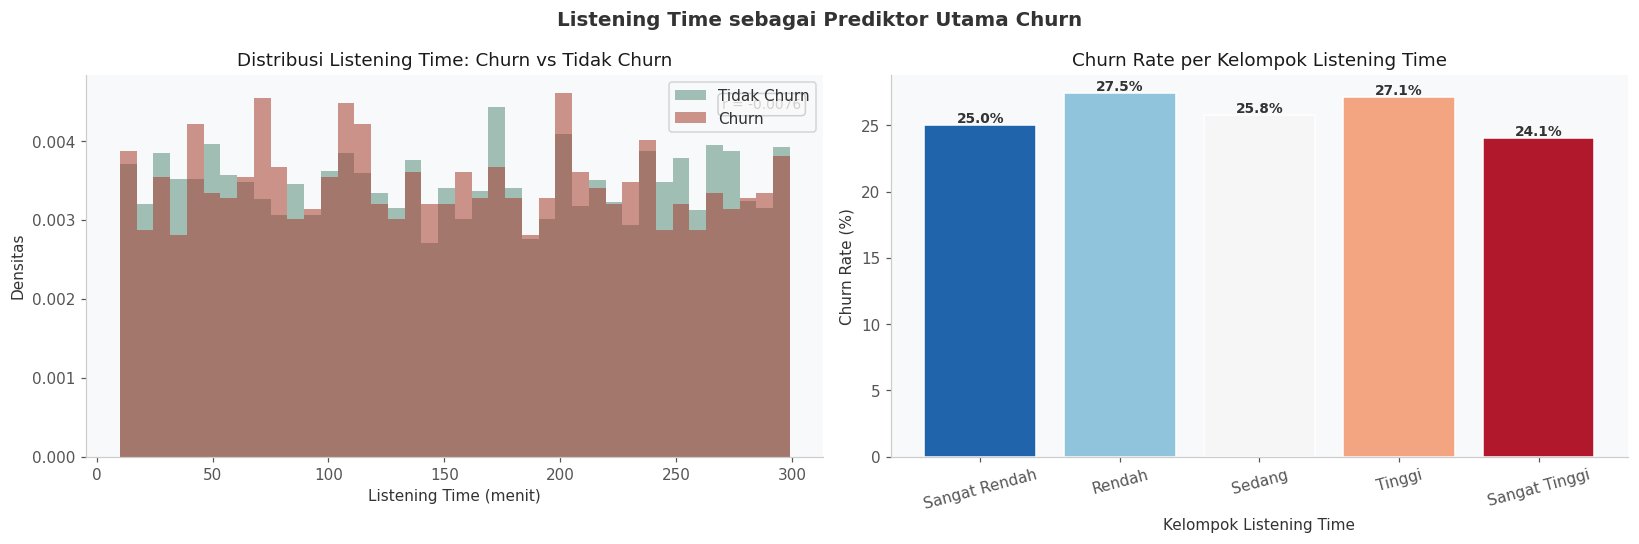

In [21]:
pb_r, pb_p = pointbiserialr(df['is_churned'], df['listening_time'])
print(f"Point-Biserial Correlation (Listening Time vs Churn): r = {pb_r:.4f}, p = {pb_p:.2e}")
print()

lt_stats = df.groupby('is_churned')['listening_time'].describe().round(2)
lt_stats.index = ['Tidak Churn', 'Churn']
display(lt_stats)

df['lt_bin'] = pd.qcut(df['listening_time'], q=5,
                       labels=['Sangat Rendah','Rendah','Sedang','Tinggi','Sangat Tinggi'])
lt_churn_bin = (
    df.groupby('lt_bin', observed=True)['is_churned']
      .agg(['mean','count'])
      .reset_index()
)
lt_churn_bin['churn_pct'] = (lt_churn_bin['mean'] * 100).round(2)

print("\nChurn Rate per Kuantil Listening Time:")
display(lt_churn_bin[['lt_bin','count','churn_pct']].rename(columns={
    'lt_bin'    : 'Kelompok Listening Time',
    'count'     : 'Jumlah Pengguna',
    'churn_pct' : 'Churn Rate (%)',
}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Listening Time sebagai Prediktor Utama Churn', fontsize=13, fontweight='semibold')

for label, color, val in [('Tidak Churn', COLORS['secondary'], 0), ('Churn', COLORS['danger'], 1)]:
    subset = df[df['is_churned'] == val]['listening_time']
    axes[0].hist(subset, bins=40, alpha=0.55, color=color, label=label, density=True, edgecolor='none')
axes[0].set_xlabel('Listening Time (menit)')
axes[0].set_ylabel('Densitas')
axes[0].set_title('Distribusi Listening Time: Churn vs Tidak Churn')
axes[0].legend()
axes[0].text(0.97, 0.94, f'r = {pb_r:.4f}', transform=axes[0].transAxes,
             ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

colors_lt = plt.cm.RdBu_r(np.linspace(0.1, 0.9, len(lt_churn_bin)))
bars_lt   = axes[1].bar(lt_churn_bin['lt_bin'].astype(str), lt_churn_bin['churn_pct'],
                         color=colors_lt, edgecolor='white')
axes[1].set_xlabel('Kelompok Listening Time')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate per Kelompok Listening Time')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars_lt, lt_churn_bin['churn_pct']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='semibold')

plt.tight_layout()
plt.savefig('fig_lt_churn.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 6. Kesimpulan dan Rekomendasi Strategis

### 6.1 Ringkasan Temuan Analisis

**Pola Aktivitas Mendengarkan**

Rata-rata aktivitas mendengarkan antar gender menunjukkan perbedaan yang tidak material — selisih kurang dari satu lagu per hari. Secara geografis, Kanada dan Pakistan mencatat engagement tertinggi, sedangkan Amerika Serikat dan Jerman berada di posisi terendah. Temuan ini signifikan karena menunjukkan bahwa intensitas pasar berkembang seperti Pakistan dan India tidak kalah dari pasar maju, dan perlu mendapat perhatian strategis yang setara.

**Validitas Metode Korelasi**

Uji distribusi memperlihatkan bahwa mayoritas variabel perilaku bersifat skewed dan tidak memenuhi asumsi normalitas Pearson. Perbandingan ketiga metode — Pearson, Kendall, dan Spearman — menghasilkan arah kesimpulan yang konsisten, namun Spearman dipilih sebagai metode final karena ketahanannya terhadap outlier dan efisiensi komputasi untuk dataset berskala ribuan baris.

**Korelasi Umur dan Gender terhadap Perilaku Mendengarkan**

Korelasi Spearman antara umur dengan listening time (ρ = −0.0127) dan skip rate (ρ = −0.0196) menunjukkan hubungan yang secara praktis tidak bermakna. Uji Kruskal-Wallis pada skip rate antar gender juga tidak signifikan (p > 0.05). Temuan ini bukan sekadar hasil yang "lemah" — ini adalah *konfirmasi empiris* bahwa selera dan kebiasaan mendengarkan di Spotify bersifat lintas demografi. Implikasinya langsung: segmentasi pengguna berbasis umur atau gender untuk keperluan rekomendasi dan retensi tidak memiliki landasan data yang memadai.

**Faktor Pendorong Churn**

Model Random Forest (akurasi 75%, cross-validation 5-fold konsisten) mengidentifikasi bahwa `listening_time` dan `songs_played_per_day` adalah prediktor churn paling kuat. Analisis Point-Biserial Correlation mempertegas hubungan ini secara statistik. Pengguna dengan listening time sangat rendah memiliki churn rate tertinggi — mengkonfirmasi bahwa *ketidakaktifan* adalah sinyal dini yang paling andal untuk mengidentifikasi pengguna berisiko.

Analisis kejenuhan iklan (ad fatigue) pada pengguna gratis menunjukkan tren peningkatan churn seiring bertambahnya frekuensi iklan. Sementara itu, uji Chi-Square membuktikan bahwa fitur offline listening tidak berhubungan secara signifikan dengan retensi (p = 0.266), menandakan bahwa fitur ini belum menjadi faktor pembeda pengalaman yang cukup kuat untuk menahan pengguna.

---

### 6.2 Rekomendasi Strategis

**1. Penerapan Sistem Deteksi Churn Berbasis Engagement Dini**

Karena listening time adalah prediktor churn terkuat, Spotify perlu membangun pipeline prediksi risiko yang berjalan secara periodik. Setiap penurunan signifikan dalam listening time mingguan seorang pengguna harus memicu protokol re-engagement otomatis — berupa kurasi playlist personal, notifikasi konten baru dari artis favorit, atau penawaran uji coba fitur Premium. Intervensi yang dilakukan sebelum pengguna benar-benar tidak aktif terbukti jauh lebih efektif dari upaya reaktif pasca-churn.

**2. Personalisasi Rekomendasi Berbasis Perilaku, Bukan Demografi**

Data secara konsisten menunjukkan bahwa umur dan gender tidak membedakan perilaku mendengarkan. Algoritma rekomendasi yang masih menggunakan asumsi demografis (misalnya, menyesuaikan genre dengan kelompok umur) perlu dievaluasi dan digeser sepenuhnya ke model berbasis behavioral fingerprint: riwayat pemutaran, durasi mendengarkan per sesi, waktu aktif, dan pola skip. Pendekatan ini akan meningkatkan relevansi rekomendasi dan secara langsung berkontribusi pada peningkatan listening time.

**3. Pembatasan Frekuensi Iklan Secara Adaptif untuk Pengguna Gratis**

Tren data menunjukkan hubungan positif antara frekuensi iklan dan probabilitas churn pada segmen pengguna gratis. Solusi yang lebih terukur dibanding pembatasan statis adalah sistem ad-capping adaptif: frekuensi iklan dikurangi secara dinamis ketika sistem mendeteksi pengguna sedang dalam sesi mendengarkan panjang atau memiliki skip rate rendah — kondisi yang menandakan engagement tinggi yang tidak boleh terganggu. Sebagai alternatif monetisasi, format Reward Ad (satu iklan video untuk sesi bebas iklan selama durasi tertentu) dapat menjaga pendapatan tanpa merusak pengalaman pendengar.

**4. Ekspansi Lokalisasi di Pasar Berkembang Berpotensi Tinggi**

India dan Pakistan mencatat engagement mendengarkan yang kompetitif dibandingkan pasar Eropa dan Amerika Utara, dengan jumlah pengguna yang substansial. Strategi yang direkomendasikan meliputi: penyesuaian harga langganan berdasarkan paritas daya beli lokal, pengembangan kurasi playlist dalam bahasa regional (Hindi, Urdu, Tamil), dan optimasi infrastruktur server untuk mengurangi latensi. Investasi di pasar ini berpotensi menghasilkan Return on Investment yang lebih tinggi dibandingkan memperdalami penetrasi di pasar jenuh.

**5. Re-evaluasi Anggaran Promosi Fitur Offline Listening**

Hasil uji Chi-Square secara tegas menunjukkan bahwa penggunaan fitur offline tidak berhubungan secara signifikan dengan retensi pengguna. Anggaran pemasaran yang selama ini dialokasikan untuk mempromosikan keunggulan mode offline perlu dipertimbangkan untuk dialihkan ke proposisi nilai yang lebih terukur dampaknya: kualitas audio lossless, eksklusivitas konten podcast, atau program loyalitas yang mendorong pengguna gratis bermigrasi ke paket berbayar melalui percobaan fitur Premium secara terbatas.

---

### 6.3 Penutup

Analisis ini menunjukkan bahwa retensi pengguna Spotify tidak ditentukan oleh siapa penggunanya secara demografis, melainkan oleh seberapa dalam mereka terlibat dengan platform secara aktif. Listening time adalah variabel tunggal yang paling konsisten membedakan pengguna yang bertahan dan yang berhenti. Dengan menempatkan peningkatan engagement aktif sebagai prioritas utama — melalui rekomendasi yang lebih relevan, intervensi dini berbasis data, dan pengelolaan iklan yang lebih empatik — Spotify memiliki fondasi yang kuat untuk mengurangi churn dan memperluas basis pendengar secara berkelanjutan.


In [22]:
print("Ringkasan Korelasi Final (Spearman)")
print("-" * 52)
print(f"  Umur vs Listening Time         : rho = {sp_age_lt:.4f}  (p = {p_age_lt:.4f})")
print(f"  Umur vs Skip Rate              : rho = {sp_age_sr:.4f}  (p = {p_age_sr:.4f})")
print(f"  Gender vs Skip Rate (Kruskal)  : H-stat, p = {p_kw:.4f}")
print(f"  Iklan vs Churn (Free, Spearman): rho = {sp_ad:.4f}  (p = {p_ad:.4f})")
print(f"  Offline vs Churn (Chi-Square)  : p = {p_chi:.4f}")
print(f"  Akurasi Model Random Forest    : {acc*100:.2f}% (CV: {cv_score.mean()*100:.2f}%)")
print("-" * 52)
print()
print("Prediktor churn teratas (Feature Importance):")
for rank, (feat, val) in enumerate(feat_imp.sort_values(ascending=False).head(5).items(), 1):
    bar_block = int(val * 250)
    print(f"  {rank}. {feat:<28} {'|' * bar_block}  {val:.4f}")
print()
print("Analisis selesai.")
print("File: 247411027_ANWAR ROHMADI.ipynb")


Ringkasan Korelasi Final (Spearman)
----------------------------------------------------
  Umur vs Listening Time         : rho = -0.0127  (p = 0.2569)
  Umur vs Skip Rate              : rho = -0.0196  (p = 0.0797)
  Gender vs Skip Rate (Kruskal)  : H-stat, p = 0.2429
  Iklan vs Churn (Free, Spearman): rho = 0.0377  (p = 0.0909)
  Offline vs Churn (Chi-Square)  : p = 0.2664
  Akurasi Model Random Forest    : 66.50% (CV: 66.34%)
----------------------------------------------------

Prediktor churn teratas (Feature Importance):
  1. listening_time               ||||||||||||||||||||||||||||||||||||||||||||||||||  0.2027
  2. songs_played_per_day         ||||||||||||||||||||||||||||||||||||||||||||||  0.1853
  3. skip_rate                    ||||||||||||||||||||||||||||||||||||||||||  0.1711
  4. age                          |||||||||||||||||||||||||||||||||||||||  0.1575
  5. country                      |||||||||||||||||||||  0.0841

Analisis selesai.
File: 247411027_ANWAR ROHMADI.ipynb
